<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/homework/Homework_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>`

# Introduction to Deep Learning with Tensorflow

In this Homework we will go through the basics of how to implement simple Deep Learning models in Python, from data preprocessing to the final evaluation and model improvements.

To do so, and for most of this notebook, we will work on an __image classification__ task. The goal here is to take raw images as input and have our model predict to which of several categories the image belongs.

You are going to solve this problem using Tensorflow. In case you want to give a try with Pytorch too, you can always use the Recitation Notebook as a good starter!



## Import Tensorflow related libraries

In [14]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# We also import other necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

In [15]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Learning an Image Classification Model from Scratch





The [fashion_mnist](https://github.com/zalandoresearch/fashion-mnist) dataset is displayed below.

![Fashion MNIST](https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/doc/img/fashion-mnist-sprite.png)




<br>


### Accessing Keras datasets

Dataset creators typically (and helpfully!) split the data into training and test for us, taking care to ensure that they are as similar as possible.

For each of those two datasets, we have the features and the dependent variable (a.k.a target or label)  



In [16]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

### First step with any new dataset: explore and visualize!

## Problem 1.1

How many images are there in the training set, and what is their shape?
How many images are there in the test set, and what is their shape?

In [17]:
### WRITE YOUR CODE HERE ###
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Problem 1.2

What is the range of the values in the first image of the training set?

In [18]:
### WRITE YOUR CODE HERE ###
print(x_train[0].min())
print(x_train[0].max())

0
255


## Problem 1.3

How many unique labels are there in the dataset? Create a list that contains the actual labels in the same order as the labels' numbers. What does label 5 correspond to?

Hint: You can find information about the labels in the [Fashion MNIST Github site](https://github.com/zalandoresearch/fashion-mnist#labels).

In [19]:
### WRITE YOUR CODE HERE ###
print("Number of unique labels: ", len(set(y_train)))

Number of unique labels:  10


## Problem 1.4

What is the maximum number of samples a class has in the training set? Is this problem a balanced classification problem?

In [20]:
### WRITE YOUR CODE HERE ###
label_counts = {}
for label in y_train:
    if label not in label_counts:
        label_counts[label] = 1
    else:
        label_counts[label] += 1
label_counts.items()

dict_items([(np.uint8(9), 6000), (np.uint8(0), 6000), (np.uint8(3), 6000), (np.uint8(2), 6000), (np.uint8(7), 6000), (np.uint8(5), 6000), (np.uint8(1), 6000), (np.uint8(6), 6000), (np.uint8(4), 6000), (np.uint8(8), 6000)])

## Problem 1.5

What is the label of the first image of the training set? Visualize the image.
Also, visualize the first 25 images from the training set in a grid plot. What is the order of the images in the second column of the grid? Make sure that the order of displaying is rows first.

Hint: You can use the add_subplot and imshow commands.


In [21]:
### WRITE YOUR CODE HERE ###
y_train[0]

np.uint8(9)

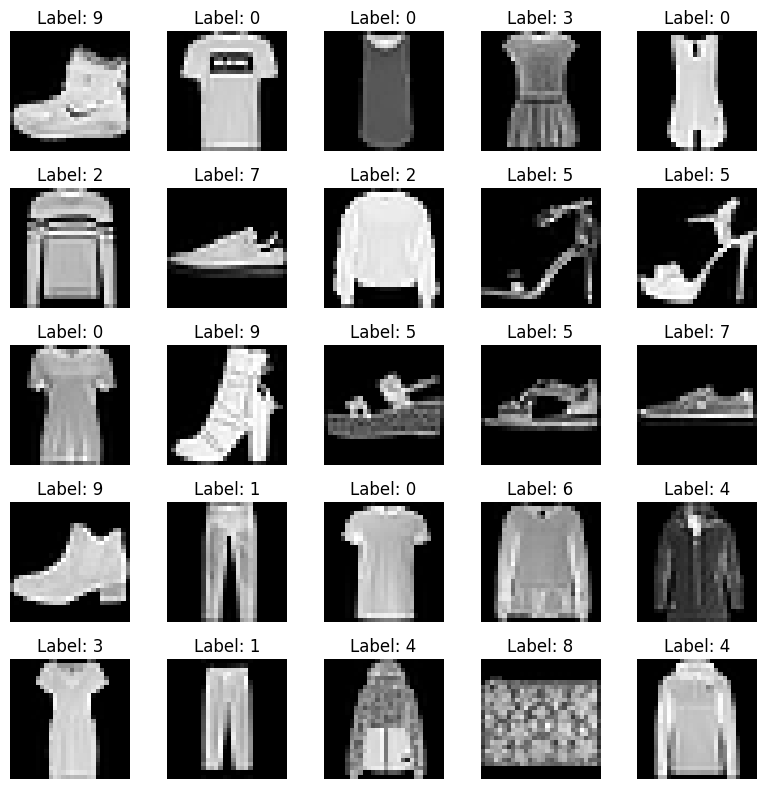

In [22]:
### WRITE YOUR CODE HERE ###
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

index = 0  # image index
for i in range(5):        # rows
    for j in range(5):    # columns
        axes[i, j].imshow(x_train[index], cmap='gray')
        axes[i, j].set_title(f"Label: {y_train[index]}")
        axes[i, j].axis('off')
        index += 1

plt.tight_layout()
plt.show()


## Building and Training a Feedforward Neural Network


Our first NN will be a plain-vanilla network with a single hidden layer.

### Data Prep

The numbers range from 0 to 255. Let's normalize to the 0-1 range by dividing everything by 255.

In [23]:
x_train = x_train / 255
x_test = x_test / 255

## Problem 1.1

Since you are first building a FeedForward Neural Network, the images need to be flattened. Conver the images to vectors; what is the shape of the training and the test set now?

In [29]:
### WRITE YOUR CODE HERE ###
x_train_flat = x_train.reshape(-1, 28*28)
print(x_train_flat.shape)
x_test_flat = x_test.reshape(-1, 28*28)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


## Problem 1.2

Create a Feedforward Neural Network with one hidden layer. The hidden layer should have 256 nodes, and the ReLU activation function applied on its output. How many nodes will the output layer have? Which activation function will you use for the output layer? Then, print the model using the model.summary() line. How many parameters does your network have?

In [25]:
### WRITE YOUR CODE HERE ###
model = ...

In [26]:
model.summary()

AttributeError: 'ellipsis' object has no attribute 'summary'

## Problem 1.3

You should now set optimization parameters. Compile the model using the appropriate loss function, the Adam optimizer with a learning rate of 0.001 and the appropriate metric (choose one of the multiple choice options in the Homework page!).

In [ ]:
### WRITE YOUR CODE HERE ###

## Problem 1.4

What is an appropriate batch size of your model out of the options provided and why?
Experiment with different number of epochs; which one would you choose?
In which range does your performance on the validation set lie?

Hint: Use the validation_split argument in the fit function (use 20% of the initial training set as validation set).

In [ ]:
### WRITE YOUR CODE HERE ###

## Problem 1.5

Evaluate the model's performance on the test set. What is the range in which the test set accuracy lies?

In [ ]:
### WRITE CODE HERE ###

## Problem 1.6

Suppose you wanted to add a second hidden layer of the same size (256 nodes) and a dropout layer between the first and the second hidden layer of the network. Define the model but don't train it. How many parameters does your model have in total now?

In [ ]:
### WRITE YOUR CODE HERE ###
model = ...

In [ ]:
model.summary()

For Fashion MNIST, the **[state of the art (SOTA)](https://paperswithcode.com/sota/image-classification-on-fashion-mnist)** accuracy is **96.91%**!

Can we get closer to that?

## A Convolutional Neural Network




We will follow the same sequence of steps as we did above:


*   Data Prep
*   Define Model
*   Set Optimization Parameters
*   Train Model
*   Evaluate Model


### Problem 1.0

The data has already been normalized so that the numbers are between 0 and 1. We don't need to do it again.

But we do need to reshape the image **vector** back into how it used to be: a 2D **matrix**. Reshape your data back in its original shape.

In [ ]:
### DEFINE THE ORIGINAL IMAGE SHAPE ###

ORIG_IMG_SHAPE = ...

x_train = x_train.reshape(x_train.shape[0], ORIG_IMG_SHAPE, ORIG_IMG_SHAPE, 1)
x_test = x_test.reshape(x_test.shape[0], ORIG_IMG_SHAPE, ORIG_IMG_SHAPE, 1)

We added the one more dimension at the end, since it corresponds to the number of channels.

In this example is not clear why we do this, but if we were working with color images, we would need an estra dimension to specify the "channel" (for example, RGB has 3 channels). Keras ConvNets are designed to work with images with multiple channels, even with gray images we need to artificially add this dimension.

### Define Model

OK, we are ready to create our very first **Convolutional Neural Network (CNN)!**

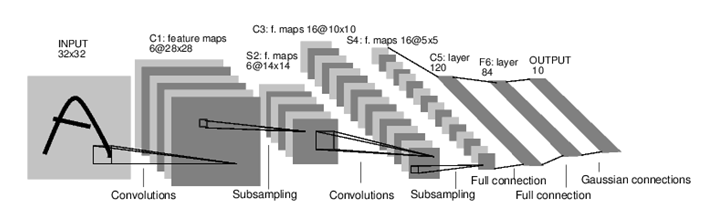

## Problem 1.1

Define a simple CNN model. It must consist of 2 Convolutional layers, the first layer must have 32 kernels and the second one 16 kernels. The kernel size should be 3x3. Use the ReLU activation function. After each Convolutional layer, make sure you are also using a max pooling layer, with pool size of 2x2.
For the fully connected part of the model, use one hidden layer and one output layer. The hidden layer should have 128 nodes.

What is the total number of parameters in your resulting model?

In [ ]:
### WRITE YOUR CODE HERE ###
model = ...

In [ ]:
model.summary()

Set the same optimization parameters as earlier.

In [ ]:
### WRITE YOUR CODE HERE ###

## Problem 1.2

Choose the same batch size and number of epochs as earlier. What is the range of the accuracy on the validation set?

In [ ]:
### WRITE YOUR CODE HERE ###

## Problem 1.3

How would you evaluate the accuracy on the test set compared to the validation set?

In [ ]:
### WRITE YOUR CODE HERE ###

## Problem 1.4

The **confusion matrix** is a good way to get a complete picture of this phenomenon. Plot the confusion matrix using the seaborn package, as we saw in Recitation. Which class has the least true positives?

In [ ]:
### WRITE YOUR CODE HERE ###